# Multi-Run BO vs. Random Search Analysis

This notebook compares the combined outputs produced by `multi_run_bo.py` and `multi_run_random_search.py`.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

RESULTS_DIR = Path("multi_run_results")
TRIAL_FILES = {
    "bo": RESULTS_DIR / "bo_all_trials.csv",
    "random_search": RESULTS_DIR / "random_search_all_trials.csv",
}
SUMMARY_FILE = RESULTS_DIR / "summary.csv"
BEST_PARAMETERS_FILE = RESULTS_DIR / "best_parameters_summary.csv"

PARAMETER_COLUMNS = [
    "preparation_capacity",
    "sorting_capacity",
    "analysis1_capacity",
    "analysis2_capacity",
    "evaluation_capacity",
    "dispatching_capacity",
    "worker_capacity",
]

PARAMETER_LABELS = [column.replace("_capacity", "").replace("analysis", "analysis ") for column in PARAMETER_COLUMNS]
METHOD_COLORS = {
    "BO": "tab:blue",
    "Random Search": "tab:orange",
}


In [11]:
def load_trials() -> pd.DataFrame:
    existing = {method: path for method, path in TRIAL_FILES.items() if path.exists()}
    missing = {method: path for method, path in TRIAL_FILES.items() if not path.exists()}

    if not existing:
        missing_text = "\n".join(f"- {path}" for path in missing.values())
        raise FileNotFoundError(
            "No combined trial CSVs found. Run these first from the BO folder:\n"
            "  python multi_run_bo.py\n"
            "  python multi_run_random_search.py\n\n"
            f"Missing files:\n{missing_text}"
        )

    if missing:
        print("Partial results loaded. Missing files:")
        for path in missing.values():
            print(f"- {path}")

    frames = []
    for method, path in existing.items():
        df = pd.read_csv(path)
        if "method" not in df.columns:
            df["method"] = method
        frames.append(df)

    trials = pd.concat(frames, ignore_index=True, sort=False)
    required = {"method", "run_index", "trial_index", "objective_mean", "best_objective_so_far"}
    missing_columns = sorted(required - set(trials.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns in trial results: {missing_columns}")

    trials["method"] = trials["method"].replace({"bo": "BO", "random_search": "Random Search"})
    return trials.sort_values(["method", "run_index", "trial_index"]).reset_index(drop=True)


trials = load_trials()
display(trials.head())
print(f"Loaded {len(trials)} trial rows from {trials['run_index'].nunique()} run indices.")

,method,run_index,trial_index,preparation_capacity,sorting_capacity,analysis1_capacity,analysis2_capacity,evaluation_capacity,dispatching_capacity,worker_capacity,...,worker_capacity_norm_mean,time_in_system_mean_norm_mean,time_in_system_std_norm_mean,objective_completed_contribution_mean,objective_late_contribution_mean,objective_station_capacity_contribution_mean,objective_worker_capacity_contribution_mean,objective_time_mean_contribution_mean,objective_time_std_contribution_mean,best_objective_so_far
0,BO,0,0,3,2,4,1,1,1,5,...,0.444444,0.766155,0.411921,-0.626365,1.744381,0.200000,0.155556,0.306462,0.0,1.780034
1,BO,0,1,4,4,2,3,5,4,9,...,0.888889,0.563673,0.297780,-0.726494,1.100144,0.533333,0.311111,0.225469,0.0,1.443564
2,BO,0,2,3,3,4,3,3,5,1,...,0.000000,1.402402,0.768668,-0.254713,2.743622,0.500000,0.000000,0.560961,0.0,1.443564
3,BO,0,3,1,3,1,5,3,3,6,...,0.555556,1.295841,0.719023,-0.368623,2.579841,0.333333,0.194444,0.518336,0.0,1.443564
4,BO,0,4,1,2,2,5,2,1,2,...,0.111111,0.824883,0.446517,-0.475858,2.178023,0.233333,0.038889,0.329953,0.0,1.443564


Loaded 1200 trial rows from 20 run indices.


## Best Objective So Far Per Run

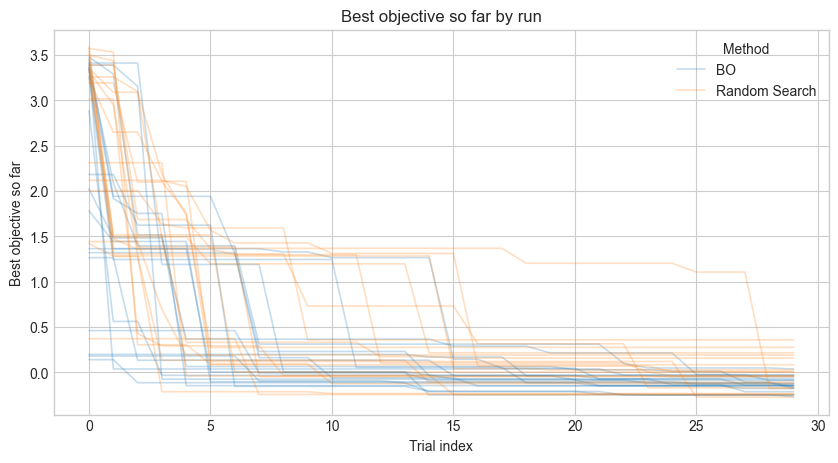

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

labeled_methods = set()
for (method, run_index), run_df in trials.groupby(["method", "run_index"], sort=False):
    label = method if method not in labeled_methods else "_nolegend_"
    labeled_methods.add(method)
    ax.plot(
        run_df["trial_index"],
        run_df["best_objective_so_far"],
        color=METHOD_COLORS.get(method),
        alpha=0.25,
        linewidth=1.2,
        label=label,
    )

ax.legend(title="Method")
ax.set_title("Best objective so far by run")
ax.set_xlabel("Trial index")
ax.set_ylabel("Best objective so far")
plt.show()


## Median With IQR Band

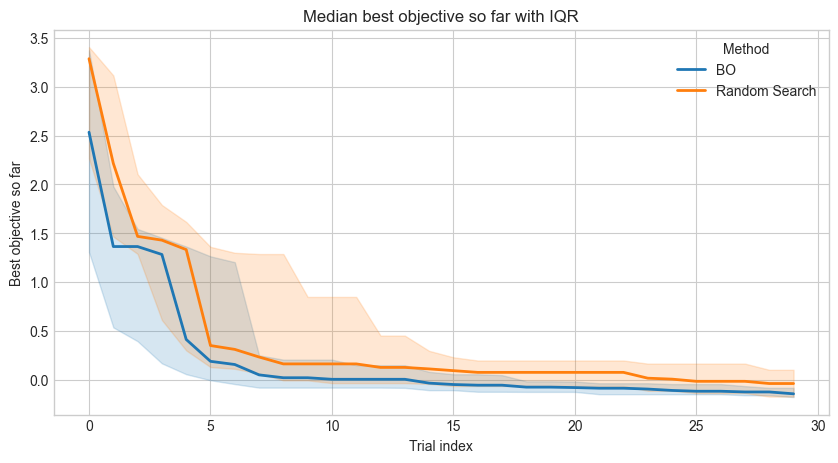

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

for method, method_df in trials.groupby("method", sort=False):
    grouped = method_df.groupby("trial_index")["best_objective_so_far"]
    stats = grouped.quantile([0.25, 0.5, 0.75]).unstack()
    stats.columns = ["q25", "median", "q75"]
    color = METHOD_COLORS.get(method)
    ax.plot(stats.index, stats["median"], linewidth=2.0, color=color, label=method)
    ax.fill_between(stats.index, stats["q25"], stats["q75"], color=color, alpha=0.18)

ax.legend(title="Method")
ax.set_title("Median best objective so far with IQR")
ax.set_xlabel("Trial index")
ax.set_ylabel("Best objective so far")
plt.show()


## Final Best Objective Per Run

C:\Users\fabia\AppData\Local\Temp\ipykernel_57572\711475105.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showmeans=True)


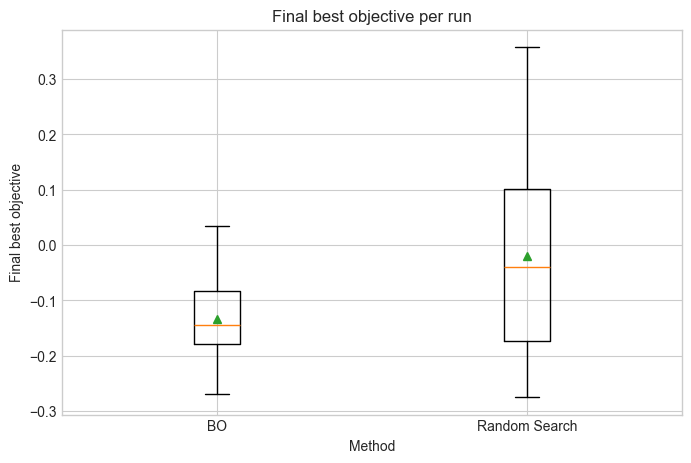

,method,run_index,final_best_objective
29,BO,0,-0.130711
59,BO,1,-0.269970
89,BO,2,-0.072062
119,BO,3,-0.249567
149,BO,4,-0.048873
179,BO,5,-0.253176
209,BO,6,0.034960
239,BO,7,-0.148483
269,BO,8,-0.087663
299,BO,9,-0.179618


In [14]:
final_trials = (
    trials.sort_values(["method", "run_index", "trial_index"])
    .groupby(["method", "run_index"], as_index=False)
    .tail(1)
    .copy()
)
final_trials["final_best_objective"] = final_trials["best_objective_so_far"]

methods = list(final_trials["method"].drop_duplicates())
data = [
    final_trials.loc[final_trials["method"] == method, "final_best_objective"].dropna()
    for method in methods
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, labels=methods, showmeans=True)
ax.set_title("Final best objective per run")
ax.set_xlabel("Method")
ax.set_ylabel("Final best objective")
plt.show()

display(final_trials[["method", "run_index", "final_best_objective"]].sort_values(["method", "run_index"]))

## Best Parameter Settings

Best parameter setting found across all runs per method:


,method,run_index,trial_index,objective_mean,objective_std,n_valid_replications,preparation_capacity,sorting_capacity,analysis1_capacity,analysis2_capacity,evaluation_capacity,dispatching_capacity,worker_capacity,total_capacity
715,Random Search,3,25,-0.274776,0.050306,30,2,5,3,2,5,2,5,24
59,BO,1,29,-0.269970,0.215256,30,2,4,5,3,3,1,6,24


Best parameter setting per run written to multi_run_results\best_parameters_summary.csv


,method,run_index,trial_index,objective_mean,objective_std,n_valid_replications,preparation_capacity,sorting_capacity,analysis1_capacity,analysis2_capacity,evaluation_capacity,dispatching_capacity,worker_capacity,total_capacity
0,BO,0,25,-0.130711,0.065186,30,4,4,5,4,4,1,7,29
1,BO,1,29,-0.269970,0.215256,30,2,4,5,3,3,1,6,24
2,BO,2,21,-0.072062,0.023645,30,4,4,5,5,5,1,7,31
3,BO,3,23,-0.249567,0.021649,30,2,5,4,3,5,1,6,26
4,BO,4,24,-0.048873,0.189699,30,5,5,4,4,4,2,7,31
5,BO,5,22,-0.253176,0.016021,30,3,5,4,2,4,3,5,26
6,BO,6,29,0.034960,0.094792,30,4,3,3,4,5,1,5,25
7,BO,7,4,-0.148483,0.629378,30,3,4,4,3,4,1,6,25
8,BO,8,14,-0.087663,0.020857,30,2,4,5,3,4,2,10,30
9,BO,9,27,-0.179618,0.053940,30,2,4,3,2,5,1,9,26


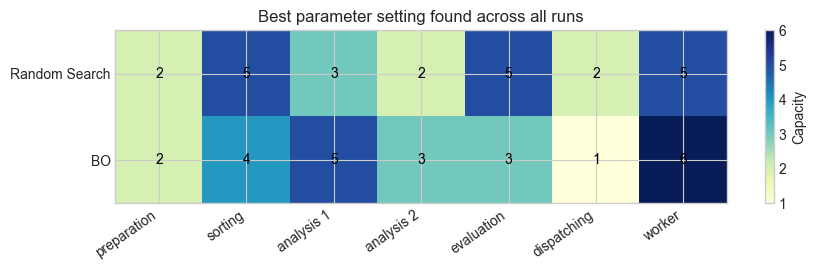

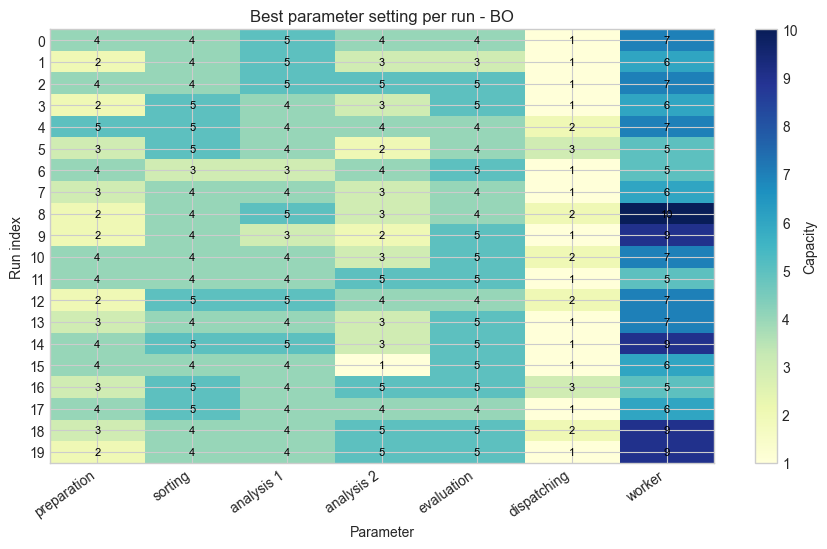

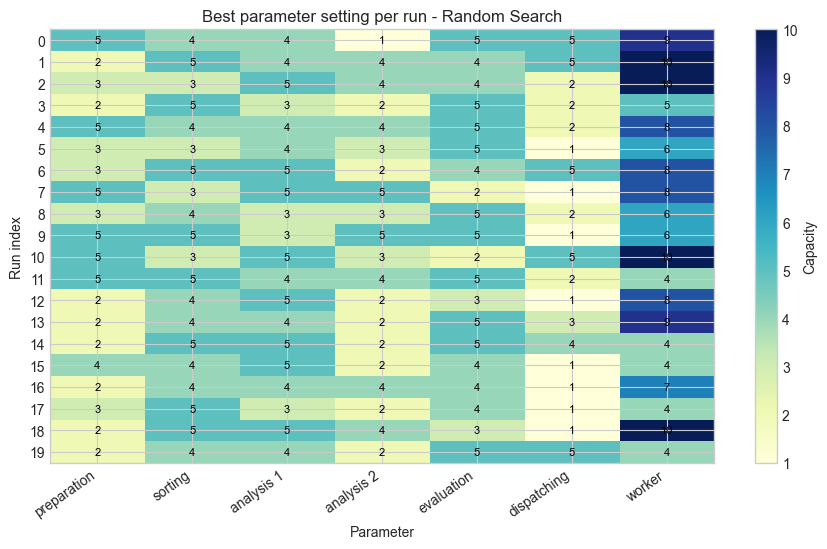

In [15]:
missing_parameters = [column for column in PARAMETER_COLUMNS if column not in trials.columns]
if missing_parameters:
    raise ValueError(f"Missing parameter columns in trial results: {missing_parameters}")

best_parameter_rows = []
for method, method_df in trials.groupby("method", sort=False):
    best_row = method_df.loc[method_df["objective_mean"].idxmin()].copy()
    best_parameter_rows.append(best_row)

best_parameters = pd.DataFrame(best_parameter_rows)
best_parameters["total_capacity"] = best_parameters[PARAMETER_COLUMNS].sum(axis=1)
best_parameter_columns = [
    "method",
    "run_index",
    "trial_index",
    "objective_mean",
    "objective_std",
    "n_valid_replications",
    *PARAMETER_COLUMNS,
    "total_capacity",
]
best_parameters = best_parameters[best_parameter_columns].sort_values("objective_mean")

print("Best parameter setting found across all runs per method:")
display(best_parameters)

best_parameters_by_run = (
    trials.loc[trials.groupby(["method", "run_index"])["objective_mean"].idxmin(), best_parameter_columns[:-1]]
    .sort_values(["method", "run_index"])
    .reset_index(drop=True)
)
best_parameters_by_run["total_capacity"] = best_parameters_by_run[PARAMETER_COLUMNS].sum(axis=1)
try:
    best_parameters_by_run.to_csv(BEST_PARAMETERS_FILE, index=False)
except PermissionError as error:
    print(f"Could not write {BEST_PARAMETERS_FILE}: {error}")
else:
    print(f"Best parameter setting per run written to {BEST_PARAMETERS_FILE}")

display(best_parameters_by_run)

global_heatmap = best_parameters.set_index("method")[PARAMETER_COLUMNS]
fig, ax = plt.subplots(figsize=(9, 2.8))
image = ax.imshow(global_heatmap.to_numpy(), aspect="auto", cmap="YlGnBu")
ax.set_title("Best parameter setting found across all runs")
ax.set_xticks(np.arange(len(PARAMETER_COLUMNS)), labels=PARAMETER_LABELS, rotation=35, ha="right")
ax.set_yticks(np.arange(len(global_heatmap.index)), labels=global_heatmap.index)
for row_idx in range(global_heatmap.shape[0]):
    for col_idx in range(global_heatmap.shape[1]):
        ax.text(col_idx, row_idx, int(global_heatmap.iloc[row_idx, col_idx]), ha="center", va="center", color="black")
fig.colorbar(image, ax=ax, label="Capacity")
plt.tight_layout()
plt.show()

for method, method_df in best_parameters_by_run.groupby("method", sort=False):
    heatmap_data = method_df.set_index("run_index")[PARAMETER_COLUMNS]
    fig_height = max(4, 0.28 * len(heatmap_data))
    fig, ax = plt.subplots(figsize=(9, fig_height))
    image = ax.imshow(heatmap_data.to_numpy(), aspect="auto", cmap="YlGnBu")
    ax.set_title(f"Best parameter setting per run - {method}")
    ax.set_xlabel("Parameter")
    ax.set_ylabel("Run index")
    ax.set_xticks(np.arange(len(PARAMETER_COLUMNS)), labels=PARAMETER_LABELS, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(heatmap_data.index)), labels=heatmap_data.index)
    for row_idx in range(heatmap_data.shape[0]):
        for col_idx in range(heatmap_data.shape[1]):
            ax.text(col_idx, row_idx, int(heatmap_data.iloc[row_idx, col_idx]), ha="center", va="center", fontsize=8, color="black")
    fig.colorbar(image, ax=ax, label="Capacity")
    plt.tight_layout()
    plt.show()


## Optional Final KPI Comparison

method,BO,Random Search
n_orders_completed_mean,948.333333,347.083333
n_orders_late_mean,0.000000,195.833333
n_orders_incomplete_mean,50.216667,649.483333
late_total_norm_mean,0.050884,0.868058
time_in_system_mean_mean,23.580238,320.841856
wip_time_in_system_mean_mean,36.832854,465.866005


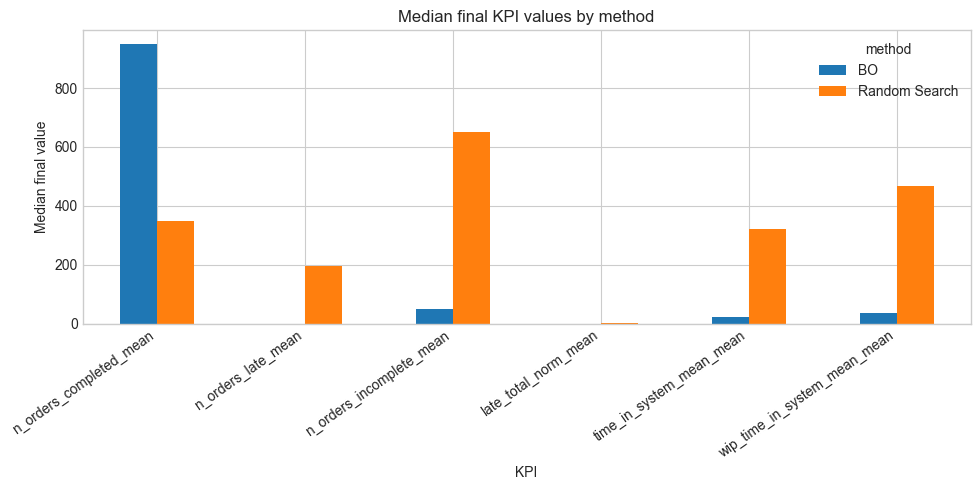

In [16]:
candidate_kpis = [
    "n_orders_completed_mean",
    "n_orders_late_mean",
    "n_orders_incomplete_mean",
    "late_total_norm_mean",
    "time_in_system_mean_mean",
    "wip_time_in_system_mean_mean",
]
available_kpis = [column for column in candidate_kpis if column in final_trials.columns]

if not available_kpis:
    print("No optional final KPI columns found in the combined trial results.")
else:
    kpi_summary = final_trials.groupby("method")[available_kpis].median().T
    display(kpi_summary)
    ax = kpi_summary.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Median final KPI values by method")
    ax.set_xlabel("KPI")
    ax.set_ylabel("Median final value")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

## Thesis Figure Export

The following cell exports the publication-ready BO figures used in the thesis results chapter. Marker: Thesis figure export: bo_default_convergence_median_iqr

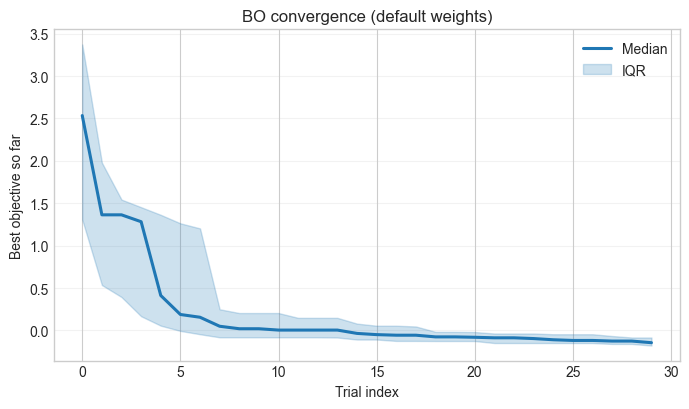

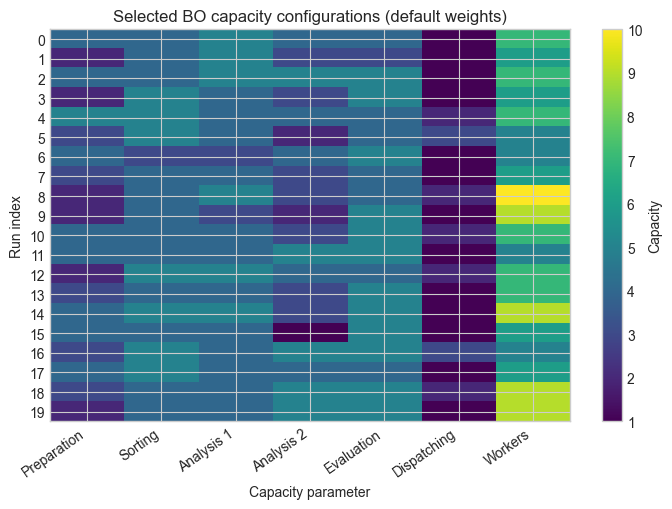

In [17]:
# Thesis figure export: BO convergence and selected capacities
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIGURE_DIR = Path("../../Thesis/BA/figures/bo_results")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

capacity_columns = [
    "preparation_capacity",
    "sorting_capacity",
    "analysis1_capacity",
    "analysis2_capacity",
    "evaluation_capacity",
    "dispatching_capacity",
    "worker_capacity",
]
capacity_labels = [
    "Preparation",
    "Sorting",
    "Analysis 1",
    "Analysis 2",
    "Evaluation",
    "Dispatching",
    "Workers",
]

trials = pd.read_csv(RESULTS_DIR / "bo_all_trials.csv")
bo_trials = trials[trials["method"].str.lower() == "bo"].copy()
bo_trials = bo_trials.sort_values(["run_index", "trial_index"])
if "best_objective_so_far" not in bo_trials.columns:
    bo_trials["best_objective_so_far"] = bo_trials.groupby("run_index")["objective_mean"].cummin()

curve = (
    bo_trials.groupby("trial_index")["best_objective_so_far"]
    .agg(median="median", q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7.0, 4.2))
x = curve["trial_index"].to_numpy(dtype=float)
median = curve["median"].to_numpy(dtype=float)
q1 = curve["q1"].to_numpy(dtype=float)
q3 = curve["q3"].to_numpy(dtype=float)
ax.plot(x, median, color="#1f77b4", linewidth=2.2, label="Median")
ax.fill_between(x, q1, q3, color="#1f77b4", alpha=0.22, label="IQR")
ax.set_title("BO convergence (default weights)")
ax.set_xlabel("Trial index")
ax.set_ylabel("Best objective so far")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(FIGURE_DIR / f"bo_default_convergence_median_iqr.{ext}", dpi=300, bbox_inches="tight")
plt.show()

best_parameters = pd.read_csv(BEST_PARAMETERS_FILE)
bo_best = best_parameters[best_parameters["method"].str.lower() == "bo"].sort_values("run_index")
heatmap_data = bo_best[capacity_columns].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
image = ax.imshow(heatmap_data, aspect="auto", cmap="viridis")
ax.set_title("Selected BO capacity configurations (default weights)")
ax.set_xlabel("Capacity parameter")
ax.set_ylabel("Run index")
ax.set_xticks(np.arange(len(capacity_labels)), capacity_labels, rotation=35, ha="right")
ax.set_yticks(np.arange(len(bo_best)), bo_best["run_index"].astype(int))
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Capacity")
fig.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(FIGURE_DIR / f"bo_default_best_capacity_heatmap.{ext}", dpi=300, bbox_inches="tight")
plt.show()

## Thesis Figure Export: BO vs Random Search

This cell exports the combined final-objective comparison for the thesis results chapter. Marker: Thesis figure export: bo_vs_random_final_objective_boxplots

C:\Users\fabia\AppData\Local\Temp\ipykernel_57572\3411971541.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(values, labels=methods, showmeans=True, patch_artist=True)
C:\Users\fabia\AppData\Local\Temp\ipykernel_57572\3411971541.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(values, labels=methods, showmeans=True, patch_artist=True)


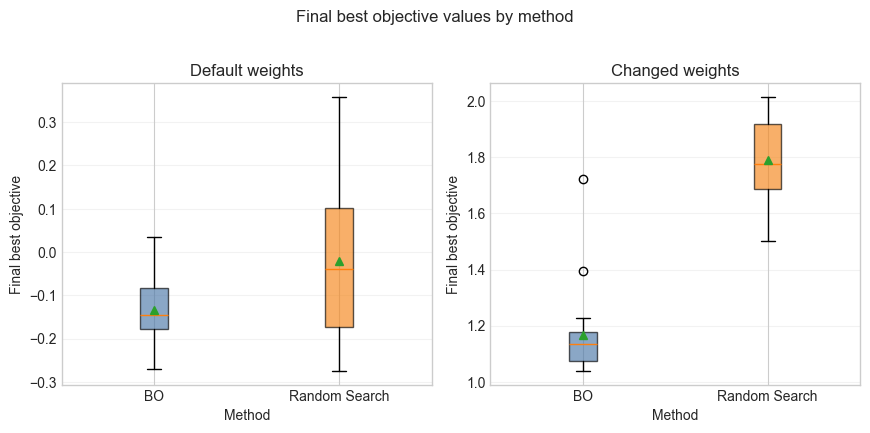

In [18]:
# Thesis figure export: BO vs Random Search final objective comparison
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

FIGURE_DIR = Path("../../Thesis/BA/figures/bo_results")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

summary_files = {
    "Default weights": Path("multi_run_results") / "summary.csv",
    "Changed weights": Path("multi_run_results_changed_weights") / "summary.csv",
}

summary_frames = []
for experiment, summary_path in summary_files.items():
    frame = pd.read_csv(summary_path)
    frame["experiment"] = experiment
    frame["method_label"] = frame["method"].str.lower().map({
        "bo": "BO",
        "random_search": "Random Search",
    }).fillna(frame["method"])
    summary_frames.append(frame)

comparison = pd.concat(summary_frames, ignore_index=True)
methods = ["BO", "Random Search"]

fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.2), sharey=False)
for ax, experiment in zip(axes, summary_files.keys()):
    data = comparison[comparison["experiment"] == experiment]
    values = [
        data.loc[data["method_label"] == method, "final_best_objective"].dropna().to_numpy()
        for method in methods
    ]
    box = ax.boxplot(values, labels=methods, showmeans=True, patch_artist=True)
    for patch, color in zip(box["boxes"], ["#4C78A8", "#F58518"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    ax.set_title(experiment)
    ax.set_xlabel("Method")
    ax.set_ylabel("Final best objective")
    ax.grid(True, axis="y", alpha=0.25)

fig.suptitle("Final best objective values by method", y=1.02)
fig.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(FIGURE_DIR / f"bo_vs_random_final_objective_boxplots.{ext}", dpi=300, bbox_inches="tight")
plt.show()

## Thesis Figure Export: Capacity by Weight Setting

This cell exports the median selected-capacity comparison for H2. Marker: Thesis figure export: bo_capacity_by_weight_setting

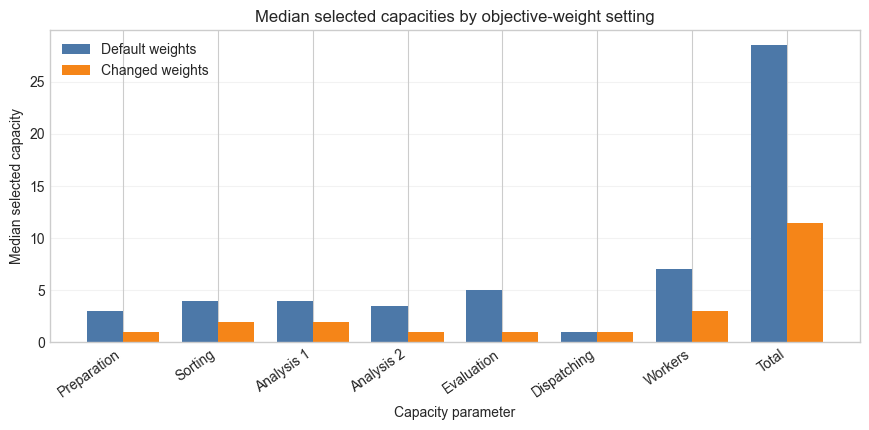

In [19]:
# Thesis figure export: median selected capacities by objective-weight setting
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIGURE_DIR = Path("../../Thesis/BA/figures/bo_results")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

capacity_columns = [
    "preparation_capacity",
    "sorting_capacity",
    "analysis1_capacity",
    "analysis2_capacity",
    "evaluation_capacity",
    "dispatching_capacity",
    "worker_capacity",
    "total_capacity",
]
capacity_labels = [
    "Preparation",
    "Sorting",
    "Analysis 1",
    "Analysis 2",
    "Evaluation",
    "Dispatching",
    "Workers",
    "Total",
]

files = {
    "Default weights": Path("multi_run_results") / "best_parameters_summary.csv",
    "Changed weights": Path("multi_run_results_changed_weights") / "best_parameters_summary.csv",
}

median_rows = []
for setting, path in files.items():
    frame = pd.read_csv(path)
    bo_frame = frame[frame["method"].str.lower() == "bo"]
    row = bo_frame[capacity_columns].median(numeric_only=True)
    row["setting"] = setting
    median_rows.append(row)

median_capacities = pd.DataFrame(median_rows).set_index("setting")

x = np.arange(len(capacity_columns))
width = 0.38
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(x - width / 2, median_capacities.loc["Default weights", capacity_columns], width, label="Default weights", color="#4C78A8")
ax.bar(x + width / 2, median_capacities.loc["Changed weights", capacity_columns], width, label="Changed weights", color="#F58518")
ax.set_title("Median selected capacities by objective-weight setting")
ax.set_xlabel("Capacity parameter")
ax.set_ylabel("Median selected capacity")
ax.set_xticks(x, capacity_labels, rotation=35, ha="right")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(FIGURE_DIR / f"bo_capacity_by_weight_setting.{ext}", dpi=300, bbox_inches="tight")
plt.show()